## Project goals

In this notebook we will:

- create an artificial gender equity dataset with 5,000 records;
- create different versions of the dataset;
- implement three sorting algorithms;
- check if every algorithm works correctly;
- measure the execution time in milliseconds;
- repeat and average the tests;
- visualize the performance results;
- recommend useful data structures for the application.


### Imports and reproducibility

Here we import the basic tools we need.

- `random` and `numpy` help us create artificial data;
- `pandas` helps us work with tables;
- `matplotlib` helps us create graphs;
- `time` helps us measure how long the algorithms take.

We also set a **random seed**.

Why do we need this?

Artificial data uses random numbers. Without a seed, the data would change every time we run the notebook.

By using the same seed, we create the same data every time. This makes the experiment repeatable and fair.


In [1]:
# basic imports
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# show complete tables more clearly
pd.set_option("display.max_columns", None)


### Create the artificial dataset

The assignment asks for at least 5,000 data points.

We create exactly **5,000 records**.

Each record represents one artificial observation for a country and year.

The dataset contains:

- country;
- region;
- year;
- female employment rate;
- male employment rate;
- employment gap;
- unpaid work by women;
- percentage of women in leadership.

The values are artificial, but they look realistic enough for a technical experiment.


In [2]:
# number of artificial records
NUMBER_OF_RECORDS = 5000

# countries and regions used in the application
country_to_region = {
    "NLD": "Western Europe",
    "BEL": "Western Europe",
    "DEU": "Western Europe",
    "FRA": "Western Europe",
    "ESP": "Southern Europe",
    "ITA": "Southern Europe",
    "PRT": "Southern Europe",
    "SWE": "Northern Europe",
    "DNK": "Northern Europe",
    "NOR": "Northern Europe",
    "FIN": "Northern Europe",
    "POL": "Eastern Europe",
    "CZE": "Eastern Europe",
    "HUN": "Eastern Europe",
    "USA": "North America",
    "CAN": "North America",
    "MEX": "North America",
    "JPN": "East Asia",
    "KOR": "East Asia",
    "AUS": "Oceania"
}

country_codes = list(country_to_region.keys())

# empty list for the new records
records = []

# create 5,000 artificial observations
for record_id in range(1, NUMBER_OF_RECORDS + 1):
    country = random.choice(country_codes)
    region = country_to_region[country]
    year = random.randint(2010, 2024)

    # create an artificial employment rate for women
    female_rate = np.clip(
        np.random.normal(67, 9),
        30,
        94
    )

    # create an artificial gender gap
    gap = np.clip(
        np.random.normal(8, 4),
        0,
        30
    )

    # male employment is female employment plus the gap
    male_rate = np.clip(
        female_rate + gap,
        35,
        98
    )

    # calculate the final gap after clipping the values
    employment_gap = male_rate - female_rate

    # create two extra gender equity measures
    unpaid_work_minutes = np.clip(
        np.random.normal(220 + employment_gap * 4, 35),
        60,
        480
    )

    women_in_leadership = np.clip(
        np.random.normal(42 - employment_gap * 0.7, 7),
        2,
        75
    )

    # store the complete observation as a dictionary
    records.append({
        "record_id": record_id,
        "country": country,
        "region": region,
        "year": year,
        "female_employment_rate": round(float(female_rate), 2),
        "male_employment_rate": round(float(male_rate), 2),
        "employment_gap": round(float(employment_gap), 2),
        "unpaid_work_minutes": round(float(unpaid_work_minutes), 2),
        "women_in_leadership_pct": round(float(women_in_leadership), 2)
    })

# convert the list into a DataFrame
df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
print("\nFirst rows:")

df.head()


Dataset shape: (5000, 9)

First rows:


,record_id,country,region,year,female_employment_rate,male_employment_rate,employment_gap,unpaid_work_minutes,women_in_leadership_pct
0,1,FRA,Western Europe,2010,71.47,78.92,7.45,272.46,47.45
1,2,DNK,Northern Europe,2013,64.89,71.96,7.06,303.53,42.43
2,3,SWE,Northern Europe,2012,62.77,72.94,10.17,244.46,31.62
3,4,FRA,Western Europe,2020,69.18,69.52,0.35,161.02,37.82
4,5,JPN,East Asia,2011,57.88,67.14,9.26,225.25,25.63


### Conclusion: Artificial dataset

- The dataset contains **5,000 rows**.
- Every row is one complete gender equity observation.
- The dataset contains several countries, regions and years.
- `employment_gap` is the value that will be sorted.
- The data is artificial and only used to test the technical performance of the application.


### Initial data checks

Before using the data, we check the structure.

In this step we will:

- count the rows and columns;
- check for missing values;
- count the countries, regions and years;
- inspect the lowest and highest employment gap.

This helps us confirm that the dataset is ready.


In [3]:
# show basic information about the artificial dataset
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isna().sum().sum())
print("Countries:", df["country"].nunique())
print("Regions:", df["region"].nunique())
print("Years:", df["year"].nunique())
print("Lowest employment gap:", df["employment_gap"].min())
print("Highest employment gap:", df["employment_gap"].max())

# show summary statistics
df.describe().round(2)


Rows: 5000
Columns: 9
Missing values: 0
Countries: 20
Regions: 7
Years: 15
Lowest employment gap: 0.0
Highest employment gap: 23.41


,record_id,year,female_employment_rate,male_employment_rate,employment_gap,unpaid_work_minutes,women_in_leadership_pct
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,2017.05,67.25,75.25,8.00,251.27,36.51
std,1443.52,4.31,9.10,9.77,3.87,38.50,7.49
min,1.00,2010.00,32.47,42.40,0.00,86.34,10.72
25%,1250.75,2013.00,61.13,68.50,5.32,225.62,31.56
50%,2500.50,2017.00,67.32,75.22,7.96,250.86,36.59
75%,3750.25,2021.00,73.38,82.12,10.64,277.06,41.49
max,5000.00,2024.00,94.00,98.00,23.41,388.57,70.14


### Conclusion: Data quality

- The dataset contains the required 5,000 records.
- No values are missing.
- The data contains multiple countries, regions and years.
- The employment gap has enough different values for the sorting experiment.
- The dataset is ready for the next step.


### Create different dataset versions

An algorithm may perform differently depending on the order of the data.

For this reason, we create four versions of the same 5,000 records.

| Dataset version | What it means | Why we test it |
|---|---|---|
| Random | The records are mixed | This represents normal unsorted data |
| Already sorted | The lowest gap is first | Some algorithms can stop early |
| Reverse sorted | The highest gap is first | This can be difficult for simple algorithms |
| Nearly sorted | Most records are in order | This represents data that only needs a small update |

The records contain the same type of information. Only the order changes.


In [4]:
# random version
random_records = records.copy()
random.shuffle(random_records)

# already sorted version
sorted_records = sorted(
    records,
    key=lambda record: record["employment_gap"]
)

# reverse-sorted version
reverse_records = sorted(
    records,
    key=lambda record: record["employment_gap"],
    reverse=True
)

# nearly sorted version
nearly_sorted_records = sorted_records.copy()

# switch 50 pairs of records
for _ in range(50):
    first_position = random.randrange(len(nearly_sorted_records))
    second_position = random.randrange(len(nearly_sorted_records))

    nearly_sorted_records[first_position], nearly_sorted_records[second_position] = (
        nearly_sorted_records[second_position],
        nearly_sorted_records[first_position]
    )

# store all versions in one dictionary
datasets = {
    "Random": random_records,
    "Already sorted": sorted_records,
    "Reverse sorted": reverse_records,
    "Nearly sorted": nearly_sorted_records
}

# check the size of every version
for name, dataset in datasets.items():
    print(name, ":", len(dataset), "records")


Random : 5000 records
Already sorted : 5000 records
Reverse sorted : 5000 records
Nearly sorted : 5000 records


### Conclusion: Dataset versions

Four dataset versions were created.

Every version contains **5,000 records**.

This allows us to test if the order of the input data changes the performance of an algorithm.


## Sorting algorithms

A sorting algorithm places values in a chosen order.

In this application, we sort complete records by `employment_gap`.

We use three algorithms:

1. Bubble Sort;
2. Merge Sort;
3. Quick Sort.

### Algorithm comparison

| Algorithm | Simple explanation | Advantage | Disadvantage | Useful for |
|---|---|---|---|---|
| Bubble Sort | Compares two neighbours and switches them | Easy to understand and can stop early | Very slow for large unsorted datasets | Learning and very small lists |
| Merge Sort | Divides the data and combines sorted parts | Fast and predictable | Needs extra memory | Large datasets where stable performance matters |
| Quick Sort | Divides values around a pivot | Often very fast | Performance depends on the pivot | General in-memory sorting |


### Bubble Sort

Bubble Sort compares two records next to each other.

If the first value is higher than the second value, the records switch places.

This continues until the complete list is sorted.

The algorithm stops early when no records need to switch.


In [5]:
def bubble_sort(data, key):
    # create a copy so the original list stays unchanged
    sorted_data = data.copy()

    # move the largest remaining value to the end
    for end_position in range(len(sorted_data) - 1, 0, -1):
        swapped = False

        # compare two records next to each other
        for position in range(end_position):
            if sorted_data[position][key] > sorted_data[position + 1][key]:
                sorted_data[position], sorted_data[position + 1] = (
                    sorted_data[position + 1],
                    sorted_data[position]
                )

                swapped = True

        # stop when the data is already sorted
        if not swapped:
            break

    return sorted_data


### Merge Sort

Merge Sort first divides the list into smaller parts.

After that, the smaller parts are combined again in the correct order.

This method normally performs well on large datasets.


In [6]:
def merge_sort(data, key):
    # a list with zero or one item is already sorted
    if len(data) <= 1:
        return data.copy()

    # split the list into two parts
    middle = len(data) // 2

    left = merge_sort(data[:middle], key)
    right = merge_sort(data[middle:], key)

    merged = []

    left_index = 0
    right_index = 0

    # compare values from both parts
    while left_index < len(left) and right_index < len(right):
        if left[left_index][key] <= right[right_index][key]:
            merged.append(left[left_index])
            left_index += 1
        else:
            merged.append(right[right_index])
            right_index += 1

    # add the remaining records
    merged.extend(left[left_index:])
    merged.extend(right[right_index:])

    return merged


### Quick Sort

Quick Sort chooses one value as the **pivot**.

Records with a lower value go before the pivot.

Records with a higher value go after the pivot.

The same process is repeated for the smaller groups.


In [7]:
def quick_sort(data, key):
    # a list with zero or one item is already sorted
    if len(data) <= 1:
        return data.copy()

    # choose the middle value as the pivot
    pivot = data[len(data) // 2][key]

    lower = [
        record for record in data
        if record[key] < pivot
    ]

    equal = [
        record for record in data
        if record[key] == pivot
    ]

    higher = [
        record for record in data
        if record[key] > pivot
    ]

    # sort the lower and higher groups
    return (
        quick_sort(lower, key)
        + equal
        + quick_sort(higher, key)
    )


### Check if the algorithms work

Performance is only useful when the result is correct.

The next function checks if every value is equal to or higher than the value before it.

We first test the algorithms on a smaller sample.

The full results are checked again during the performance test.


In [8]:
def is_sorted(data, key):
    # compare every value with the next value
    return all(
        data[index][key] <= data[index + 1][key]
        for index in range(len(data) - 1)
    )


# store the algorithms in a dictionary
algorithms = {
    "Bubble Sort": bubble_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

# use a smaller sample for the first check
sample = random_records[:500]

for algorithm_name, algorithm in algorithms.items():
    result = algorithm(
        sample,
        key="employment_gap"
    )

    print(
        algorithm_name,
        "correctly sorted:",
        is_sorted(result, "employment_gap")
    )


Bubble Sort correctly sorted: True
Merge Sort correctly sorted: True
Quick Sort correctly sorted: True


### Conclusion: Algorithm check

All three algorithms returned the records in the correct order.

This means the algorithms are ready for the performance experiment.


## Performance experiment

We now measure how long every algorithm needs to sort the data.

### Why repeat the test?

A computer may be slightly faster or slower during one run.

One result could therefore be unusual.

Every algorithm is tested **three times** on every dataset version.

We calculate:

- the average time;
- the fastest time;
- the slowest time;
- the standard deviation.

The time is reported in **milliseconds**.

A lower time means that the algorithm was faster.


In [9]:
def measure_performance(
    algorithm,
    data,
    key,
    repetitions=3
):
    times = []

    # create the correct answer once
    correct_values = sorted(
        record[key] for record in data
    )

    # repeat the test
    for _ in range(repetitions):
        start_time = time.perf_counter()

        result = algorithm(data, key)

        end_time = time.perf_counter()

        # check the complete result
        result_values = [
            record[key] for record in result
        ]

        if result_values != correct_values:
            raise ValueError("The algorithm did not sort correctly.")

        # convert seconds to milliseconds
        time_ms = (end_time - start_time) * 1000

        times.append(time_ms)

    return {
        "average_ms": np.mean(times),
        "fastest_ms": np.min(times),
        "slowest_ms": np.max(times),
        "standard_deviation_ms": np.std(times, ddof=1)
    }


### Run all simulations

Every algorithm is tested on:

- random data;
- already sorted data;
- reverse-sorted data;
- nearly sorted data.

This gives us 12 different algorithm and dataset combinations.


In [10]:
# empty list for all results
performance_results = []

# test every algorithm on every dataset version
for dataset_name, dataset in datasets.items():
    for algorithm_name, algorithm in algorithms.items():
        result = measure_performance(
            algorithm=algorithm,
            data=dataset,
            key="employment_gap",
            repetitions=3
        )

        performance_results.append({
            "dataset": dataset_name,
            "algorithm": algorithm_name,
            "records": len(dataset),
            "average_ms": result["average_ms"],
            "fastest_ms": result["fastest_ms"],
            "slowest_ms": result["slowest_ms"],
            "standard_deviation_ms": result["standard_deviation_ms"]
        })

# convert the results into a DataFrame
results_df = pd.DataFrame(performance_results)

# sort the table for easier reading
results_df = results_df.sort_values(
    ["dataset", "average_ms"]
).reset_index(drop=True)

results_df.round(3)


,dataset,algorithm,records,average_ms,fastest_ms,slowest_ms,standard_deviation_ms
0,Already sorted,Bubble Sort,5000,0.285,0.243,0.337,0.048
1,Already sorted,Quick Sort,5000,2.777,2.719,2.811,0.050
2,Already sorted,Merge Sort,5000,3.277,3.104,3.406,0.156
3,Nearly sorted,Quick Sort,5000,2.694,2.657,2.756,0.054
4,Nearly sorted,Merge Sort,5000,3.736,3.680,3.784,0.052
5,Nearly sorted,Bubble Sort,5000,535.163,531.869,540.189,4.422
6,Random,Quick Sort,5000,4.326,4.173,4.456,0.143
7,Random,Merge Sort,5000,5.446,5.355,5.516,0.083
8,Random,Bubble Sort,5000,794.637,774.695,830.200,30.874
9,Reverse sorted,Quick Sort,5000,2.587,2.533,2.639,0.053


### Performance results

The table above shows the measured time for every test.

- `average_ms` is the main performance result;
- `fastest_ms` is the fastest run;
- `slowest_ms` is the slowest run;
- `standard_deviation_ms` shows how much the runs changed.

A lower average means better speed.

A lower standard deviation means more stable measurements.


### Visualize the performance results

The graph compares the average execution time.

A logarithmic scale is used.

Why?

Bubble Sort can be much slower than Merge Sort and Quick Sort.

Without a logarithmic scale, the faster bars may become too small to see.


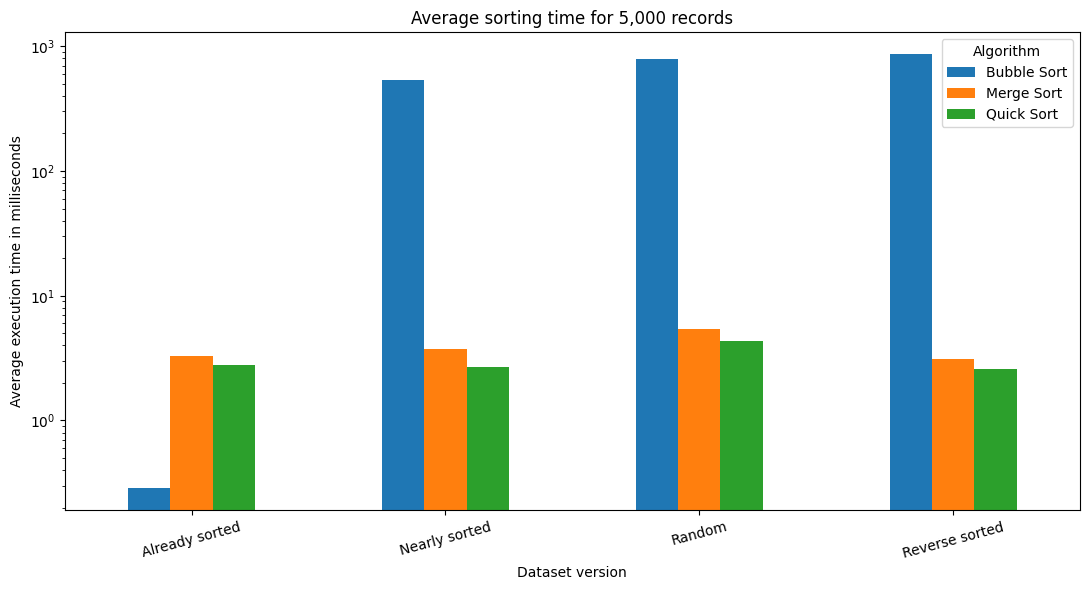

In [11]:
# create a table for the grouped bar chart
performance_pivot = results_df.pivot(
    index="dataset",
    columns="algorithm",
    values="average_ms"
)

# create the graph
ax = performance_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average sorting time for 5,000 records")
plt.xlabel("Dataset version")
plt.ylabel("Average execution time in milliseconds")
plt.yscale("log")
plt.xticks(rotation=15)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()


### Average performance per algorithm

The next graph combines the four dataset versions.

It shows the overall average time for every algorithm.


,algorithm,average_time_ms,average_standard_deviation_ms
0,Quick Sort,3.096,0.075
1,Merge Sort,3.899,0.090
2,Bubble Sort,548.882,10.960


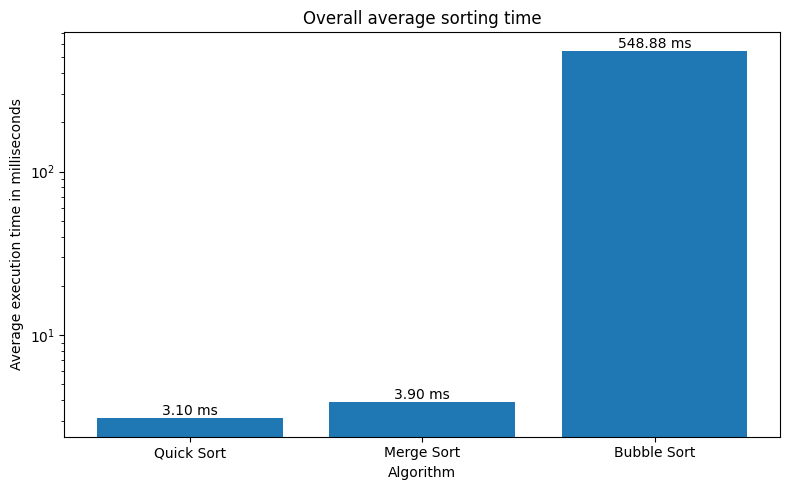

In [12]:
# calculate the overall average per algorithm
algorithm_summary = (
    results_df
    .groupby("algorithm", as_index=False)
    .agg(
        average_time_ms=("average_ms", "mean"),
        average_standard_deviation_ms=(
            "standard_deviation_ms",
            "mean"
        )
    )
    .sort_values("average_time_ms")
    .reset_index(drop=True)
)

display(algorithm_summary.round(3))

# create a simple bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    algorithm_summary["algorithm"],
    algorithm_summary["average_time_ms"]
)

plt.title("Overall average sorting time")
plt.xlabel("Algorithm")
plt.ylabel("Average execution time in milliseconds")
plt.yscale("log")

# show the result above every bar
for bar, value in zip(
    bars,
    algorithm_summary["average_time_ms"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} ms",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### Automatic result summary

The exact timing can change slightly when the notebook is run on another computer.

For this reason, the next code creates the conclusion directly from the measured results.


In [13]:
# show the fastest and slowest algorithm for every dataset version
for dataset_name in results_df["dataset"].unique():
    dataset_results = results_df[
        results_df["dataset"] == dataset_name
    ]

    fastest = dataset_results.loc[
        dataset_results["average_ms"].idxmin()
    ]

    slowest = dataset_results.loc[
        dataset_results["average_ms"].idxmax()
    ]

    print(dataset_name)
    print(
        "Fastest:",
        fastest["algorithm"],
        f"({fastest['average_ms']:.3f} ms)"
    )
    print(
        "Slowest:",
        slowest["algorithm"],
        f"({slowest['average_ms']:.3f} ms)"
    )
    print()

# show the overall fastest algorithm
overall_fastest = algorithm_summary.iloc[0]
overall_slowest = algorithm_summary.iloc[-1]

print("Overall conclusion")
print(
    "Fastest algorithm:",
    overall_fastest["algorithm"],
    f"({overall_fastest['average_time_ms']:.3f} ms)"
)
print(
    "Slowest algorithm:",
    overall_slowest["algorithm"],
    f"({overall_slowest['average_time_ms']:.3f} ms)"
)


Already sorted
Fastest: Bubble Sort (0.285 ms)
Slowest: Merge Sort (3.277 ms)

Nearly sorted
Fastest: Quick Sort (2.694 ms)
Slowest: Bubble Sort (535.163 ms)

Random
Fastest: Quick Sort (4.326 ms)
Slowest: Bubble Sort (794.637 ms)

Reverse sorted
Fastest: Quick Sort (2.587 ms)
Slowest: Bubble Sort (865.443 ms)

Overall conclusion
Fastest algorithm: Quick Sort (3.096 ms)
Slowest algorithm: Bubble Sort (548.882 ms)


### Conclusion: Sorting performance

The experiment shows that the structure of the data affects performance.

Bubble Sort is easy to understand, but it is normally too slow for a large application.

Its early-stop check can help when the data is already sorted.

Merge Sort gives predictable performance across different dataset versions.

Quick Sort is also efficient and usually performs well for data stored in memory.

For a real application, I would not use Bubble Sort for 5,000 or more records.

I would choose Merge Sort or Quick Sort when implementing the algorithm manually.

In a production Python application, I would normally use the built-in `sorted()` function or Pandas `sort_values()`. These tools are optimized and well tested.


### Time complexity

Time complexity explains how quickly the amount of work grows when the dataset becomes larger.

It does not show the exact number of milliseconds.

It shows the general growth pattern.

| Algorithm | Best case | Average case | Worst case |
|---|---:|---:|---:|
| Bubble Sort | O(n) | O(n²) | O(n²) |
| Merge Sort | O(n log n) | O(n log n) | O(n log n) |
| Quick Sort | O(n log n) | O(n log n) | O(n²) |

`O(n²)` grows quickly when the number of records increases.

`O(n log n)` normally grows more slowly.

This explains why Merge Sort and Quick Sort are more suitable for large datasets.


## Data structure recommendations

A data structure is a way to store and organize information.

The correct data structure makes it easier to:

- sort data;
- find data;
- remove duplicates;
- group records;
- create application filters.

### Recommended structures

| Information | Data structure | Application use |
|---|---|---|
| All observations | List | Store records that need to be sorted |
| One observation | Dictionary | Store labelled values such as country, year and gap |
| Country summaries | Dictionary | Quickly find the result for one country |
| Unique regions and years | Set | Create clean dropdown filters without duplicates |
| Country and year combination | Tuple | Create a fixed lookup key |
| Region and country groups | Nested dictionary | Build grouped dashboard pages |


### Data structure 1: List

A list stores multiple items in one variable.

Lists keep their order and can contain duplicate values.

In this application, a list is useful for the records that need to be sorted.


In [14]:
# create a list with all employment gaps
employment_gap_list = [
    record["employment_gap"]
    for record in records
]

print("Number of values:", len(employment_gap_list))
print("First five values:", employment_gap_list[:5])
print(
    "Average employment gap:",
    round(
        sum(employment_gap_list)
        / len(employment_gap_list),
        2
    )
)


Number of values: 5000
First five values: [7.45, 7.06, 10.17, 0.35, 9.26]
Average employment gap: 8.0


### Data structure 2: Dictionary

A dictionary stores information as key-value pairs.

The key can be a country code.

The value can contain the calculated summary for that country.

This makes a country result easy to find.


In [15]:
# create an empty dictionary
country_summary = {}

# add every record to the correct country
for record in records:
    country = record["country"]

    if country not in country_summary:
        country_summary[country] = {
            "record_count": 0,
            "total_gap": 0
        }

    country_summary[country]["record_count"] += 1
    country_summary[country]["total_gap"] += record["employment_gap"]

# calculate the average gap for every country
for country in country_summary:
    country_summary[country]["average_gap"] = (
        country_summary[country]["total_gap"]
        / country_summary[country]["record_count"]
    )

print("Number of countries:", len(country_summary))
print("\nExample for the Netherlands:")
print(country_summary["NLD"])


Number of countries: 20

Example for the Netherlands:
{'record_count': 209, 'total_gap': 1704.3800000000003, 'average_gap': 8.154928229665073}


### Use the dictionary in the application

The NGO may want to see the countries with the largest average employment gap.

The dictionary already contains the information needed for this result.


In [16]:
# create a simple table from the dictionary
country_table = pd.DataFrame([
    {
        "country": country,
        "records": values["record_count"],
        "average_employment_gap": values["average_gap"]
    }
    for country, values in country_summary.items()
])

# show the five highest artificial averages
country_table = country_table.sort_values(
    "average_employment_gap",
    ascending=False
).reset_index(drop=True)

country_table.head().round(2)


,country,records,average_employment_gap
0,FRA,243,8.39
1,FIN,262,8.30
2,SWE,251,8.29
3,CZE,263,8.26
4,NLD,209,8.15


### Data structure 3: Set

A set stores unique values.

Duplicates are removed automatically.

This is useful for application filters.

For example, a region should only appear once in a dropdown menu.


In [17]:
# create unique filter options
available_regions = {
    record["region"]
    for record in records
}

available_years = {
    record["year"]
    for record in records
}

print("Available regions:")
print(sorted(available_regions))

print("\nAvailable years:")
print(sorted(available_years))


Available regions:
['East Asia', 'Eastern Europe', 'North America', 'Northern Europe', 'Oceania', 'Southern Europe', 'Western Europe']

Available years:
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


### Data structure 4: Tuple as a dictionary key

A tuple stores a fixed combination of values.

In this example, the tuple contains:

`(country, year)`

The tuple is used as a dictionary key.

This helps the application quickly find records for one country in one year.


In [18]:
# create an index with country-year tuple keys
country_year_index = {}

for record in records:
    key = (
        record["country"],
        record["year"]
    )

    if key not in country_year_index:
        country_year_index[key] = []

    country_year_index[key].append(record)

# example lookup
example_key = ("NLD", 2024)

print(
    "Number of country-year combinations:",
    len(country_year_index)
)

print(
    "Records for",
    example_key,
    ":",
    len(country_year_index.get(example_key, []))
)


Number of country-year combinations: 300
Records for ('NLD', 2024) : 10


### Conclusion: Data structures

The recommended data structures have different jobs.

- A **list** is useful for records that need to be sorted.
- A **dictionary** is useful for labelled records and country summaries.
- A **set** is useful for unique filter options.
- A **tuple** is useful as a fixed lookup key.

Using the correct structure makes the application easier to understand and more efficient.


## Final technical recommendation

For the Gender Equity Employment Gap Monitor, I recommend:

### Sorting

- Do not use Bubble Sort for large unsorted datasets.
- Use Merge Sort when predictable performance is important.
- Use Quick Sort for efficient in-memory sorting.
- Use Python `sorted()` or Pandas `sort_values()` in the real production application.

### Data structures

- Use lists for collections of observations.
- Use dictionaries for observations and country summaries.
- Use sets for unique filters.
- Use tuple keys for country and year lookups.

### Application architecture

For the small prototype, Python lists and dictionaries are enough.

For a real NGO application with millions of records, the data should be stored in a database.

Python can then request only the information needed for one page or analysis.

### Limitations

- The dataset is artificial.
- The timing can change on another computer.
- This experiment measures execution time, but not memory use.
- Real decisions require validated and current gender equity data.
- More testing is needed before building a production application.


## Final conclusion

This project shows that algorithm choice matters when an application sorts large amounts of data.

All three algorithms produced the correct result, but they did not need the same amount of time.

Simple algorithms are useful for learning, but efficient algorithms are more suitable for large datasets.

The experiment also shows that data structures have different purposes.

Choosing the correct algorithm and data structure helps make an application faster, clearer and easier to maintain.

The Gender Equity Employment Gap Monitor could use these technical building blocks to help an NGO explore large gender equity datasets more efficiently.
